# SupplyPrescript

## AI-Powered Supply Chain Risk Prediction

### Machine Learning Workflow

Author:
Syed Mohammed Khalid Hussaini

Algorithm:
XGBoost Classifier

Dataset:
Dynamic Supply Chain Logistics Dataset

# Project Objective

The objective of this project is to predict the risk level of supply chain deliveries using machine learning.

The project follows these stages:

1. Data Preprocessing
2. Feature Engineering
3. Data Preparation
4. Model Training
5. Model Evaluation
6. Feature Importance Analysis

In [3]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/dynamic_supply_chain_logistics_dataset_with_country.csv"
)

df.head()

,warehouse_inventory_level,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,cargo_condition_status,route_risk_level,customs_clearance_time,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,product_id,supplier_id,supplier_country
0,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S1,Greece
1,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S2,South Korea
2,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S3,Ethiopia
3,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,High Risk,8.175281,P0857,P0857_S1,Iran
4,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,High Risk,8.175281,P0857,P0857_S2,Guatemala


In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (113097, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113097 entries, 0 to 113096
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   warehouse_inventory_level        113097 non-null  float64
 1   handling_equipment_availability  113097 non-null  float64
 2   order_fulfillment_status         113097 non-null  float64
 3   weather_condition_severity       113097 non-null  float64
 4   shipping_costs                   113097 non-null  float64
 5   supplier_reliability_score       113097 non-null  float64
 6   lead_time_days                   113097 non-null  float64
 7   historical_demand                113097 non-null  float64
 8   cargo_condition_status           113097 non-null  float64
 9   route_risk_level                 113097 non-null  float64
 10  customs_clearance_time           113097 non-null  float64
 11  disruption_likelihood_score      1130

# Data Preprocessing

The following preprocessing steps were performed:

- Removed unnecessary columns
- Checked missing values
- Encoded target variable
- Saved cleaned dataset

In [5]:
cleaned = pd.read_csv(
    "../data/processed/cleaned_supply_chain.csv"
)

cleaned.head()

,warehouse_inventory_level,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,cargo_condition_status,route_risk_level,customs_clearance_time,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,supplier_country
0,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,2,9.110682,Greece
1,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,2,9.110682,South Korea
2,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,2,9.110682,Ethiopia
3,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,0,8.175281,Iran
4,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,0,8.175281,Guatemala


# Feature Engineering

New business-oriented features were created:

- Inventory Coverage
- Supplier Efficiency
- Logistics Risk
- Delay Impact

In [6]:
feature_df = pd.read_csv(
    "../data/processed/feature_engineered_supply_chain.csv"
)

feature_df.head()

,warehouse_inventory_level,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,cargo_condition_status,route_risk_level,customs_clearance_time,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,supplier_country,inventory_coverage,supplier_efficiency,logistics_risk,delay_impact
0,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,2,9.110682,Greece,9.685460,0.315237,539.640504,8.065606
1,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,2,9.110682,South Korea,9.685460,0.315237,539.640504,8.065606
2,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,2,9.110682,Ethiopia,9.685460,0.315237,539.640504,8.065606
3,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,0,8.175281,Iran,0.074642,0.034041,6155.596180,4.448805
4,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,0,8.175281,Guatemala,0.074642,0.034041,6155.596180,4.448805


In [7]:
feature_df[
    [
        "inventory_coverage",
        "supplier_efficiency",
        "logistics_risk",
        "delay_impact"
    ]
].describe()

,inventory_coverage,supplier_efficiency,logistics_risk,delay_impact
count,1.130970e+05,1.130970e+05,113097.000000,113097.000000
mean,1.896768e-01,1.341685e-01,3220.955840,3.624199
std,6.769604e-01,1.382286e-01,2834.711619,3.628735
min,1.320985e-16,4.519352e-11,0.008712,-1.999987
25%,3.386896e-03,2.576139e-02,978.989226,0.313064
50%,3.229954e-02,7.826938e-02,2121.913490,3.027733
75%,9.975353e-02,2.070963e-01,5151.122788,6.914193
max,9.792463e+00,4.999931e-01,9999.678439,9.999984


# Data Preparation

The dataset was prepared by:

- One-Hot Encoding supplier_country
- Splitting into Training and Testing datasets

In [8]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

print(X_train.shape)
print(X_test.shape)

(90477, 112)
(22620, 112)


# Model Training

Model Used:

XGBoost Classifier

Parameters:

- 100 Trees
- Learning Rate = 0.1
- Maximum Depth = 6

In [11]:
import joblib

model = joblib.load("../models/xgboost_model.pkl")

model

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


# Model Evaluation

After training the XGBoost classifier, the model was evaluated on the testing dataset to measure its performance.

The following evaluation metrics were used:

- **Accuracy**: Measures the overall percentage of correct predictions.
- **Precision**: Measures how many of the predicted risk classes were correct.
- **Recall**: Measures how many actual risk cases were correctly identified.
- **F1 Score**: The harmonic mean of precision and recall, providing a balanced performance measure.
- **Classification Report**: Shows precision, recall, F1-score, and support for each risk class.
- **Confusion Matrix**: Displays the number of correct and incorrect predictions for each class.

These metrics help determine how well the model generalizes to unseen supply chain data.

Accuracy : 0.9999

Precision : 0.9999

Recall : 0.9999

F1 Score : 0.9999

## Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing the actual risk classifications with the predicted classifications.

- The diagonal values represent correctly classified samples.
- The off-diagonal values represent misclassified samples.

A strong model has high values along the diagonal and very few off-diagonal errors.

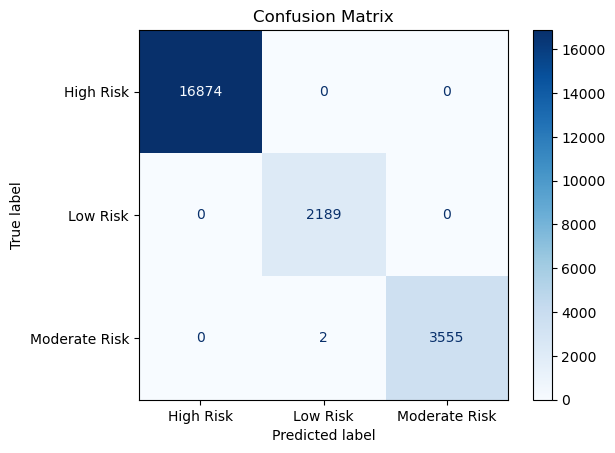

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
import pandas as pd

# Load model
model = joblib.load("../models/xgboost_model.pkl")
# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Predict
y_pred = model.predict(X_test)

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["High Risk", "Low Risk", "Moderate Risk"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [17]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import joblib

# Load model
model = joblib.load("../models/xgboost_model.pkl")

# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Predict
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display as a table
cm_df = pd.DataFrame(
    cm,
    index=["Actual High Risk", "Actual Low Risk", "Actual Moderate Risk"],
    columns=[
        "Predicted High Risk",
        "Predicted Low Risk",
        "Predicted Moderate Risk"
    ]
)

cm_df

,Predicted High Risk,Predicted Low Risk,Predicted Moderate Risk
Actual High Risk,16874,0,0
Actual Low Risk,0,2189,0
Actual Moderate Risk,0,2,3555


# Feature Importance Analysis

Feature importance helps us understand which variables contributed the most to the model's predictions.

A higher importance score indicates that the feature had a greater influence on predicting the supply chain risk classification.

The following table and chart show the ten most important features identified by the trained XGBoost model.

In [18]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load the trained model
model = joblib.load("../models/xgboost_model.pkl")

# Load the training features
X_train = pd.read_csv("../data/processed/X_train.csv")

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
importance_df.head(10)

,Feature,Importance
11,disruption_likelihood_score,0.973373
24,supplier_country_Bangladesh,0.002754
3,weather_condition_severity,0.002683
14,inventory_coverage,0.002158
5,supplier_reliability_score,0.001764
2,order_fulfillment_status,0.001640
9,route_risk_level,0.001372
4,shipping_costs,0.001233
17,delay_impact,0.001181
1,handling_equipment_availability,0.001135


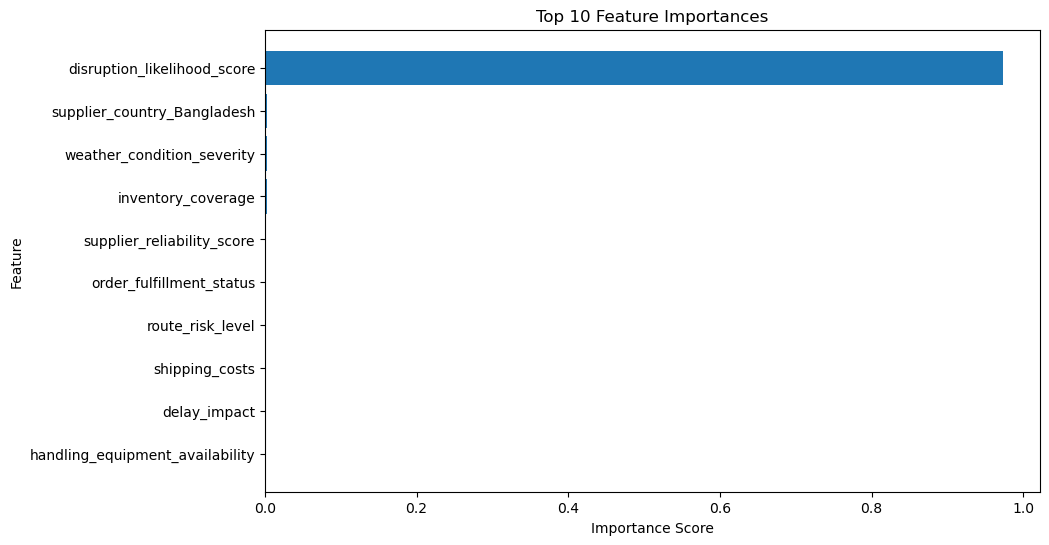

In [19]:
plt.figure(figsize=(10,6))

top10 = importance_df.head(10)

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## Interpretation

The feature importance analysis indicates that **disruption_likelihood_score** is the most influential variable for predicting supply chain risk.

Its importance score is significantly higher than the other features, suggesting that it carries most of the predictive information used by the XGBoost model.

Other features such as:

- supplier_country
- weather_condition_severity
- inventory_coverage
- supplier_reliability_score
- route_risk_level

also contribute to the prediction, but their influence is comparatively much smaller.

This analysis helps explain why the model achieved very high predictive performance.

# Model Validation

To validate the model, the feature disruption_likelihood_score was temporarily removed.

Results:

Accuracy dropped from

99.99%

to

75.15%

This confirmed that disruption_likelihood_score is the dominant predictor in the dataset.

# Conclusion

The XGBoost model successfully predicts supply chain risk with high accuracy.

The model achieved:

Accuracy : 99.99%

Precision : 99.99%

Recall : 99.99%

F1 Score : 99.99%

Feature importance analysis showed that disruption_likelihood_score contributes the most to the prediction.